In [480]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

## Data Cleaning & Pre-processing

In [481]:
# Load raw datasets (2 files)
df1 = pd.read_csv('Kumasi_Pharmacy_Face_to_Face_Interaction_DB.csv')
df2 = pd.read_csv('Kumasi_Pharmacy_Informal_Supply_DB.csv')

combined_df = pd.concat([df1, df2], ignore_index=True)

# Combine them vertically
combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'])
combined_df['Hour'] = combined_df['Timestamp'].dt.hour

print("Initial data merge complete. Total records:", len(combined_df))

Initial data merge complete. Total records: 4250


In [482]:
# First 5 rows
combined_df.head()

,Transaction_ID,Timestamp,Location_Cluster,Medication_Name_Entry,Prescription_Status,Quantity_Dispensed,Dispensing_Format,Customer_Persona,Data_Traceability,Hour
0,30001,2026-05-24 21:00:00,Kwadaso Commercial,Red and Yellow,0,2,Loose Capsules,Commuter,0,21
1,30002,2026-06-24 10:00:00,Manhyia District,3-day drug,0,6,Loose Capsules,Street Vendor,0,10
2,30003,2026-06-07 14:00:00,Ayigya University Junction,Flagyl,0,2,Loose Capsules,Petty Trader,0,14
3,30004,2026-05-29 14:00:00,Tafo Market Area,Azithro,0,2,Loose Capsules,Commuter,0,14
4,30005,2026-06-14 11:00:00,Tafo Market Area,Clox,0,4,Loose Capsules,Artisan/Mechanic,0,11


#### Missing Data Handling

In [483]:
# Checking sum of missing values
print(combined_df.isnull().sum())

# For 'Medication_Name_Entry', if it's missing, we label it as 'Unknown Antibiotic'
combined_df['Medication_Name_Entry'] = combined_df['Medication_Name_Entry'].fillna('Unknown Antibiotic')

# For 'Customer_Persona', if it's missing we label it as 'General Public'
combined_df['Customer_Persona'] = combined_df['Customer_Persona'].fillna('General Public')

Transaction_ID             0
Timestamp                  0
Location_Cluster           0
Medication_Name_Entry    128
Prescription_Status        0
Quantity_Dispensed         0
Dispensing_Format          0
Customer_Persona          20
Data_Traceability          0
Hour                       0
dtype: int64


#### Cleaned and Combined Mapping Block

In [484]:
# Map medications to their pharmacological classes
class_mapping = {
    # Penicillins
    'Amoxicillin': 'Penicillins',
    'Cloxacillin': 'Penicillins',
    'Clox': 'Penicillins',
    'Red and Yellow': 'Penicillins', # Common informal name for Amoxicillin/Cloxacillin capsules
    
    # Macrolides
    'Azithromycin': 'Macrolides',
    'Azithro': 'Macrolides',
    '3-day drug': 'Macrolides',     # Common informal reference to Azithromycin courses
    
    # Nitroimidazoles
    'Metronidazole': 'Nitroimidazoles',    # Common informal reference to Flagyl
    'Flagyl': 'Nitroimidazoles',
    
    # Fluoroquinolones
    'Ciprofloxacin': 'Fluoroquinolones',   # Common informal reference to Cipro 
    
    # Unclassified
    'Unknown Antibiotic': 'Unclassified'
}

# Apply the mapping again
combined_df['Antibiotic_Class'] = combined_df['Medication_Name_Entry'].map(class_mapping)

# Fill any remaining unmapped anomalies as Unclassified
combined_df['Antibiotic_Class'] = combined_df['Antibiotic_Class'].fillna('Unclassified')

combined_df.head()

,Transaction_ID,Timestamp,Location_Cluster,Medication_Name_Entry,Prescription_Status,Quantity_Dispensed,Dispensing_Format,Customer_Persona,Data_Traceability,Hour,Antibiotic_Class
0,30001,2026-05-24 21:00:00,Kwadaso Commercial,Red and Yellow,0,2,Loose Capsules,Commuter,0,21,Penicillins
1,30002,2026-06-24 10:00:00,Manhyia District,3-day drug,0,6,Loose Capsules,Street Vendor,0,10,Macrolides
2,30003,2026-06-07 14:00:00,Ayigya University Junction,Flagyl,0,2,Loose Capsules,Petty Trader,0,14,Nitroimidazoles
3,30004,2026-05-29 14:00:00,Tafo Market Area,Azithro,0,2,Loose Capsules,Commuter,0,14,Macrolides
4,30005,2026-06-14 11:00:00,Tafo Market Area,Clox,0,4,Loose Capsules,Artisan/Mechanic,0,11,Penicillins


In [485]:
# Standardize names to ensure geographic hotspots are calculated correctly
location_mapping = {
    'Tafo Mrkt': 'Tafo Market Area',
    'Tafo Market': 'Tafo Market Area',
    'Kejetia Station': 'Kejetia Lorry Station',
    'Suame': 'Suame Magazine (Industrial)'
}

# Rename the column
combined_df = combined_df.rename(columns={'Medication_Name_Entry': 'Medication_Name'})

combined_df['Location_Cluster'] = combined_df['Location_Cluster'].replace(location_mapping)
combined_df.head()

,Transaction_ID,Timestamp,Location_Cluster,Medication_Name,Prescription_Status,Quantity_Dispensed,Dispensing_Format,Customer_Persona,Data_Traceability,Hour,Antibiotic_Class
0,30001,2026-05-24 21:00:00,Kwadaso Commercial,Red and Yellow,0,2,Loose Capsules,Commuter,0,21,Penicillins
1,30002,2026-06-24 10:00:00,Manhyia District,3-day drug,0,6,Loose Capsules,Street Vendor,0,10,Macrolides
2,30003,2026-06-07 14:00:00,Ayigya University Junction,Flagyl,0,2,Loose Capsules,Petty Trader,0,14,Nitroimidazoles
3,30004,2026-05-29 14:00:00,Tafo Market Area,Azithro,0,2,Loose Capsules,Commuter,0,14,Macrolides
4,30005,2026-06-14 11:00:00,Tafo Market Area,Clox,0,4,Loose Capsules,Artisan/Mechanic,0,11,Penicillins


In [486]:
# 1. Map local aliases to generic names
med_mapping = {
    'Red and Yellow': 'Amoxicillin', 
    'Amoxil': 'Amoxicillin', 
    'Amox': 'Amoxicillin',
    'Yellow Tab': 'Ciprofloxacin', 
    'Cipro 500': 'Ciprofloxacin',
    'Black and Red': 'Cloxacillin', 
    'Clox': 'Cloxacillin',
    'Flagyl': 'Metronidazole', 
    '3-day drug': 'Azithromycin'
}

# Apply replacement to newly named column (Medication_Name)
combined_df['Medication_Name'] = combined_df['Medication_Name'].replace(med_mapping)

# 2. # Classify generics into target WHO/GRAM pharmacological classes
class_mapping = {
    'Amoxicillin': 'Penicillins', 
    'Cloxacillin': 'Penicillins',
    'Ciprofloxacin': 'Fluoroquinolones', 
    'Azithromycin': 'Macrolides',
    'Metronidazole': 'Nitroimidazoles'
}

# 3. # Add target flag: 1 if informal sale without record, 0 otherwise
combined_df['Data_Loss_Flag'] = ((combined_df['Prescription_Status'] == 0) & 
                                (combined_df['Data_Traceability'] == 0)).astype(int)

# FIrst 5 rows for verification
combined_df.head()

,Transaction_ID,Timestamp,Location_Cluster,Medication_Name,Prescription_Status,Quantity_Dispensed,Dispensing_Format,Customer_Persona,Data_Traceability,Hour,Antibiotic_Class,Data_Loss_Flag
0,30001,2026-05-24 21:00:00,Kwadaso Commercial,Amoxicillin,0,2,Loose Capsules,Commuter,0,21,Penicillins,1
1,30002,2026-06-24 10:00:00,Manhyia District,Azithromycin,0,6,Loose Capsules,Street Vendor,0,10,Macrolides,1
2,30003,2026-06-07 14:00:00,Ayigya University Junction,Metronidazole,0,2,Loose Capsules,Petty Trader,0,14,Nitroimidazoles,1
3,30004,2026-05-29 14:00:00,Tafo Market Area,Azithro,0,2,Loose Capsules,Commuter,0,14,Macrolides,1
4,30005,2026-06-14 11:00:00,Tafo Market Area,Cloxacillin,0,4,Loose Capsules,Artisan/Mechanic,0,11,Penicillins,1


#### Date & Time Splitting 

In [487]:
# 1. Extract the Date (MM-DD-YYYY)
combined_df['Date'] = combined_df['Timestamp'].dt.strftime('%m-%d-%Y')

# 2. Extract the Hour of Day
combined_df['Hour'] = combined_df['Timestamp'].dt.hour

# 3. Drop the original Timestamp column
combined_df = combined_df.drop('Timestamp', axis=1)
combined_df.head()

,Transaction_ID,Location_Cluster,Medication_Name,Prescription_Status,Quantity_Dispensed,Dispensing_Format,Customer_Persona,Data_Traceability,Hour,Antibiotic_Class,Data_Loss_Flag,Date
0,30001,Kwadaso Commercial,Amoxicillin,0,2,Loose Capsules,Commuter,0,21,Penicillins,1,05-24-2026
1,30002,Manhyia District,Azithromycin,0,6,Loose Capsules,Street Vendor,0,10,Macrolides,1,06-24-2026
2,30003,Ayigya University Junction,Metronidazole,0,2,Loose Capsules,Petty Trader,0,14,Nitroimidazoles,1,06-07-2026
3,30004,Tafo Market Area,Azithro,0,2,Loose Capsules,Commuter,0,14,Macrolides,1,05-29-2026
4,30005,Tafo Market Area,Cloxacillin,0,4,Loose Capsules,Artisan/Mechanic,0,11,Penicillins,1,06-14-2026


#### Check for duplicate rows

In [488]:
# Check how many exact duplicate rows exist
print(f"Duplicate rows found: {combined_df.duplicated().sum()}")

Duplicate rows found: 0


#### Creation of the Operational Risk Metric (Data Loss Flag)

In [489]:
# Create a 'Data_Loss_Flag' (1 if it's an informal sale with no record, 0 otherwise)
combined_df['Data_Loss_Flag'] = ((combined_df['Prescription_Status'] == 0) & 
                                (combined_df['Data_Traceability'] == 0)).astype(int)
combined_df.head()

,Transaction_ID,Location_Cluster,Medication_Name,Prescription_Status,Quantity_Dispensed,Dispensing_Format,Customer_Persona,Data_Traceability,Hour,Antibiotic_Class,Data_Loss_Flag,Date
0,30001,Kwadaso Commercial,Amoxicillin,0,2,Loose Capsules,Commuter,0,21,Penicillins,1,05-24-2026
1,30002,Manhyia District,Azithromycin,0,6,Loose Capsules,Street Vendor,0,10,Macrolides,1,06-24-2026
2,30003,Ayigya University Junction,Metronidazole,0,2,Loose Capsules,Petty Trader,0,14,Nitroimidazoles,1,06-07-2026
3,30004,Tafo Market Area,Azithro,0,2,Loose Capsules,Commuter,0,14,Macrolides,1,05-29-2026
4,30005,Tafo Market Area,Cloxacillin,0,4,Loose Capsules,Artisan/Mechanic,0,11,Penicillins,1,06-14-2026


#### Data Types

In [490]:
# Check the data type of every column
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Transaction_ID       4250 non-null   int64
 1   Location_Cluster     4250 non-null   str  
 2   Medication_Name      4250 non-null   str  
 3   Prescription_Status  4250 non-null   int64
 4   Quantity_Dispensed   4250 non-null   int64
 5   Dispensing_Format    4250 non-null   str  
 6   Customer_Persona     4250 non-null   str  
 7   Data_Traceability    4250 non-null   int64
 8   Hour                 4250 non-null   int32
 9   Antibiotic_Class     4250 non-null   str  
 10  Data_Loss_Flag       4250 non-null   int64
 11  Date                 4250 non-null   str  
dtypes: int32(1), int64(5), str(6)
memory usage: 382.0 KB


#### Summary of the numeric columns

In [491]:
combined_df[['Quantity_Dispensed', 'Hour']].describe()

,Quantity_Dispensed,Hour
count,4250.000000,4250.000000
mean,4.486824,13.807294
std,2.716968,4.508645
min,1.000000,6.000000
25%,2.000000,10.000000
50%,4.000000,14.000000
75%,5.000000,18.000000
max,10.000000,21.000000


#### Category Consistency Check

In [492]:
# Check unique values to spot sneaky duplicates caused by typos or casing
print(combined_df['Dispensing_Format'].unique())
print(combined_df['Customer_Persona'].unique())

<StringArray>
['Loose Capsules', 'Half Strip', 'Full Blister Strip']
Length: 3, dtype: str
<StringArray>
[        'Commuter',    'Street Vendor',     'Petty Trader',
 'Artisan/Mechanic',   'Nursing Mother',          'Student',
         'Traveler',   'Local Resident',   'General Public']
Length: 9, dtype: str


In [493]:
# Save the definitively clean dataset
combined_df.to_csv('kumasi_pharmacy_clean_final.csv', index=False)
print("\nSuccess! data is now fully cleaned and ready for Analysis.")


Success! data is now fully cleaned and ready for Analysis.


## Deep Insight Analysis & Visualizations

In [494]:
# Check the final count of your Antibiotic Classes
print("--- Data Distribution by Antibiotic Class ---")
print(combined_df['Antibiotic_Class'].value_counts())


--- Data Distribution by Antibiotic Class ---
Antibiotic_Class
Unclassified        3037
Macrolides           494
Penicillins          377
Nitroimidazoles      293
Fluoroquinolones      49
Name: count, dtype: int64


In [495]:
hotspots = combined_df['Location_Cluster'].value_counts()
print("--- Top Informal Antibiotic Hotspots ---")
print(hotspots)

--- Top Informal Antibiotic Hotspots ---
Location_Cluster
Tafo Market Area               831
Ayigya University Junction     667
Manhyia District               483
Suame Magazine (Industrial)    477
Kwadaso Commercial             474
Kejetia Hub                    389
Adum Commercial                319
Bantama High Street            318
Bantama Residential            155
Asafo Transit                  137
Name: count, dtype: int64


## 1. Transaction Volume by Hour of Day

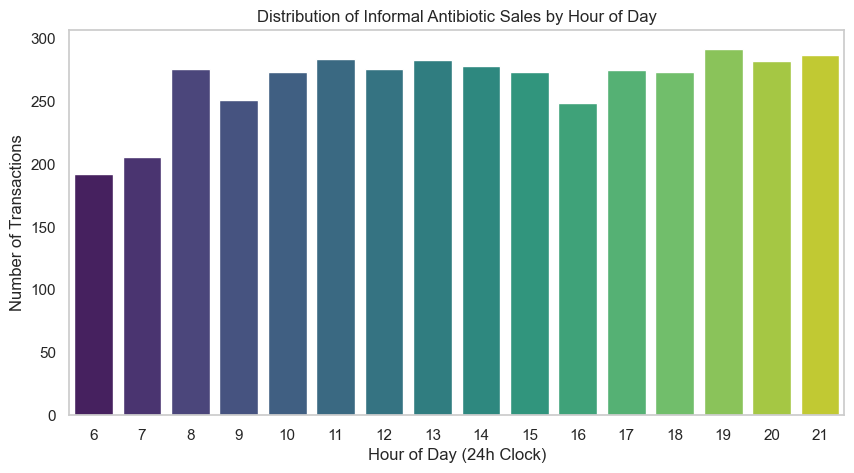

In [496]:
plt.figure(figsize=(10, 5))
sns.countplot(data=combined_df, x='Hour', hue=combined_df['Hour'].astype(str), palette='viridis', legend=False)
plt.title('Distribution of Informal Antibiotic Sales by Hour of Day')
plt.xlabel('Hour of Day (24h Clock)')
plt.ylabel('Number of Transactions')
plt.grid(False)
plt.show()

## 2. Regional Data Traceability Analysis

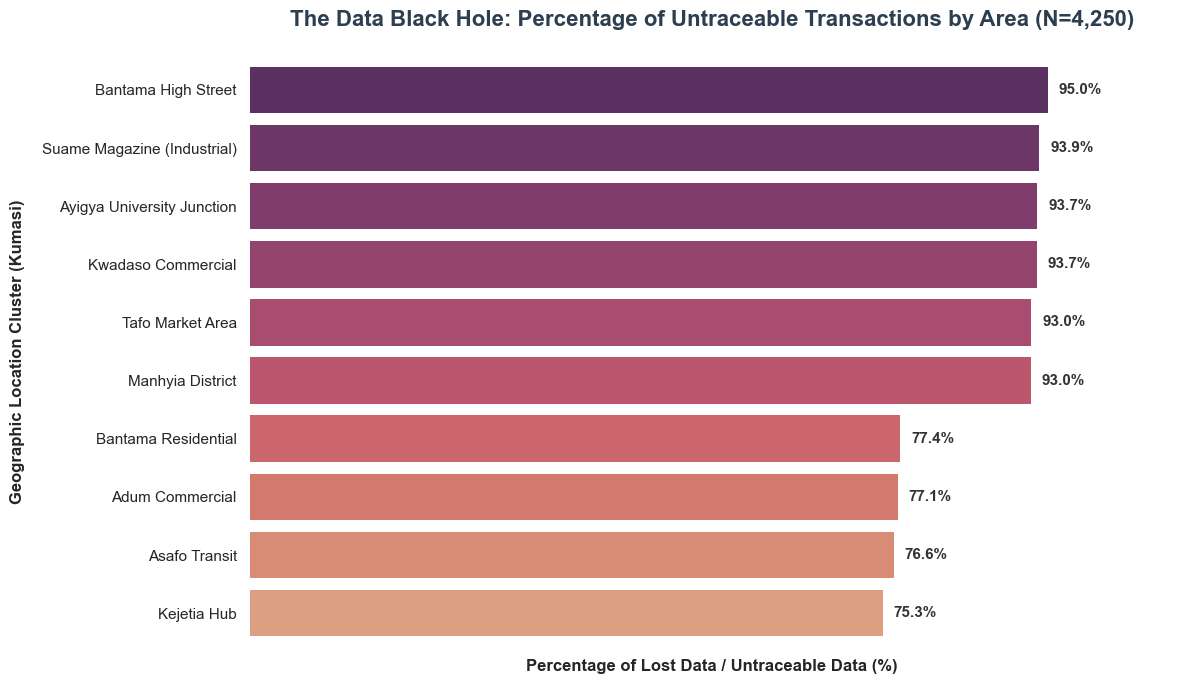

In [497]:
invisible_data = (
    combined_df.groupby('Location_Cluster')['Data_Loss_Flag']
    .mean() * 100
).reset_index()

# Sort the data dynamically from highest loss to lowest loss
invisible_data = invisible_data.sort_values(by='Data_Loss_Flag', ascending=False)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid") 

ax = sns.barplot(
    x='Data_Loss_Flag', 
    y='Location_Cluster', 
    data=invisible_data, 
    hue='Location_Cluster',  
    palette='flare_r',     
    legend=False,           
    edgecolor='none'
)

# --- DYNAMIC DATA LABELS ---
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=8, fontsize=11, fontweight='bold', color='#333333')

# --- AXIS AND TITLE REFINEMENTS ---
plt.title('The Data Black Hole: Percentage of Untraceable Transactions by Area (N=4,250)', 
          fontsize=16, fontweight='bold', pad=25, color='#2c3e50')

plt.xlabel('Percentage of Lost Data / Untraceable Data (%)', fontsize=12, fontweight='semibold', labelpad=12)
plt.ylabel('Geographic Location Cluster (Kumasi)', fontsize=12, fontweight='semibold', labelpad=12)
plt.xlim(0, 110)
ax.set_xticks([]) 

sns.despine(left=True, bottom=True)
plt.tick_params(axis='y', which='major', labelsize=11)

plt.tight_layout()
plt.show()

## 3. Prescription Status by Antibiotic Class

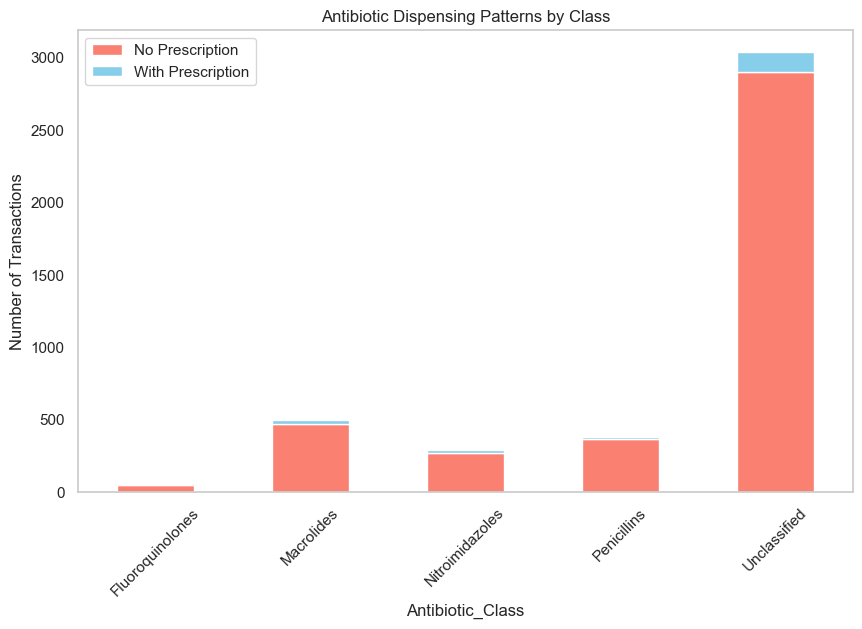

In [498]:
# Compare Prescription vs. Non-Prescription sales by Class
risk_analysis = pd.crosstab(combined_df['Antibiotic_Class'], combined_df['Prescription_Status'])
risk_analysis.columns = ['No Prescription', 'With Prescription']

risk_analysis.plot(kind='bar', stacked=True, figsize=(10, 6), color=['salmon', 'skyblue'])
plt.title('Antibiotic Dispensing Patterns by Class')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

## 4. Operational Peak Times Timeline

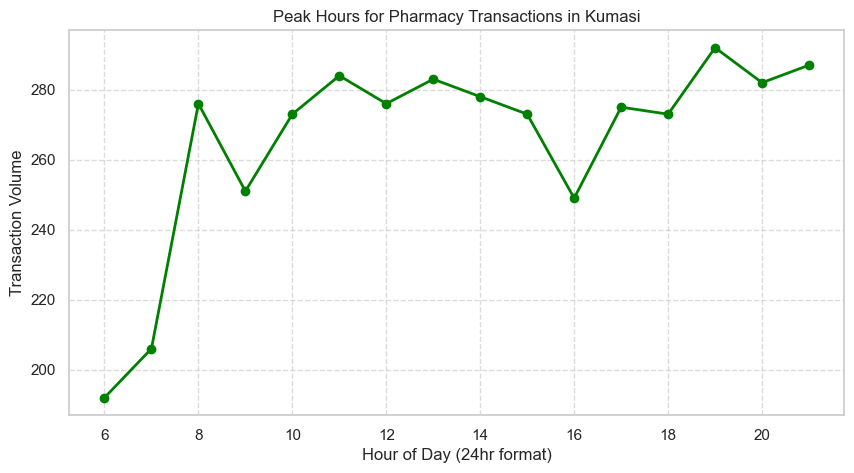

In [499]:
# Plot sales activity by hour
hourly_sales = combined_df.groupby('Hour').size()

plt.figure(figsize=(10, 5))
hourly_sales.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Peak Hours for Pharmacy Transactions in Kumasi')
plt.xlabel('Hour of Day (24hr format)')
plt.ylabel('Transaction Volume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5. Customer Persona vs. Pharmacological Class Matrix

In [500]:
demographic_distribution = pd.crosstab(combined_df['Customer_Persona'], combined_df['Antibiotic_Class'])
print("--- Antibiotic Class Purchases by Customer Persona ---")
print(demographic_distribution.T)

--- Antibiotic Class Purchases by Customer Persona ---
Customer_Persona  Artisan/Mechanic  Commuter  General Public  Local Resident  \
Antibiotic_Class                                                               
Fluoroquinolones                 0         0               0              14   
Macrolides                      52        58               3              38   
Nitroimidazoles                 35        27               5              27   
Penicillins                     57        49               0              13   
Unclassified                   383       383              12             148   

Customer_Persona  Nursing Mother  Petty Trader  Street Vendor  Student  \
Antibiotic_Class                                                         
Fluoroquinolones               0            13              0        9   
Macrolides                    63            97             62       63   
Nitroimidazoles               31            53             31       46   
Penicillins   

## 6. Dosage Fragmentation & Compliance Evaluation

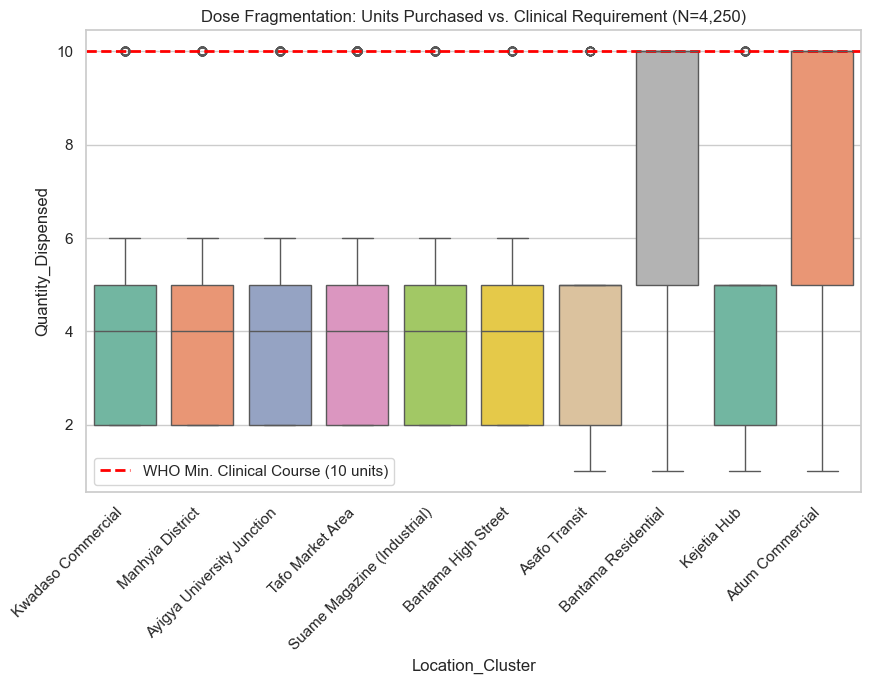

In [501]:
# Average units per transaction vs. Location
dose_analysis = combined_df.groupby('Location_Cluster')['Quantity_Dispensed'].mean()

# Visualization
plt.figure(figsize=(10, 6))

sns.boxplot(x='Location_Cluster', y='Quantity_Dispensed', hue='Location_Cluster', data=combined_df, palette='Set2', legend=False)
plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='WHO Min. Clinical Course (10 units)')
plt.legend(loc='upper right')

plt.title('Dose Fragmentation: Units Purchased vs. Clinical Requirement (N=4,250)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

## 7. Customer Risk Profiling (Informal Purchase Rates)

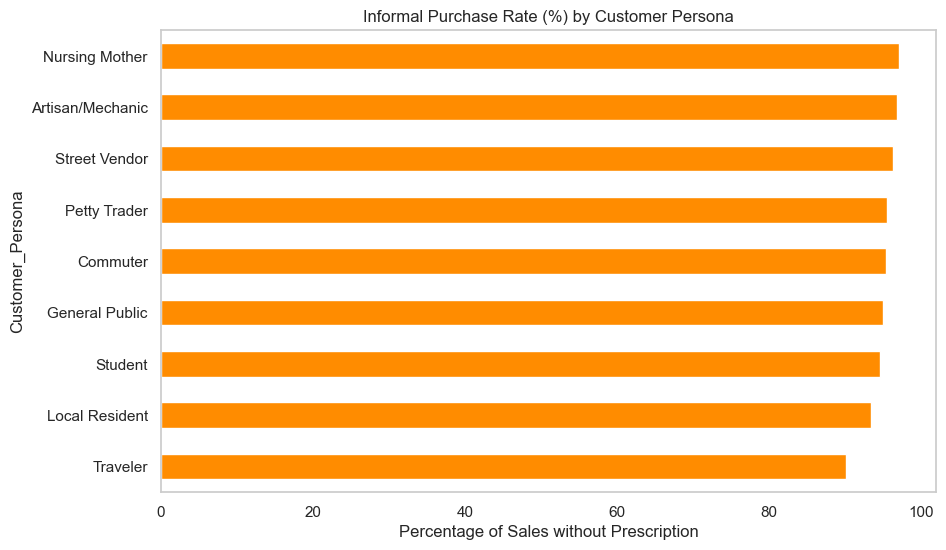

In [502]:
# Which persona is the "riskiest"?
persona_risk = pd.crosstab(combined_df['Customer_Persona'], combined_df['Prescription_Status'], normalize='index') * 100

# Plotting the "Informal Rate" by Persona
persona_risk[0].sort_values().plot(kind='barh', color='darkorange', figsize=(10, 6))
plt.title('Informal Purchase Rate (%) by Customer Persona')
plt.xlabel('Percentage of Sales without Prescription')
plt.grid(False)
plt.show()

## 8. Data Loss Risk by Packaging / Dispensing Format

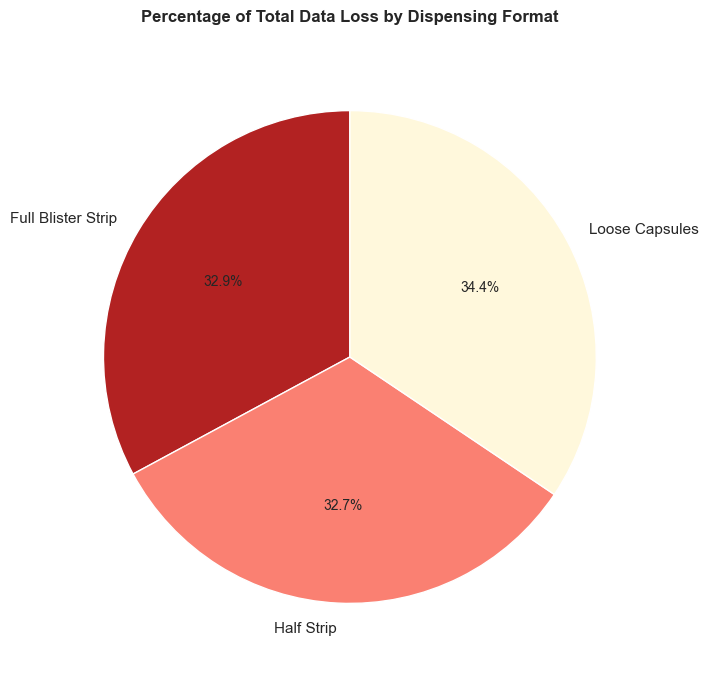

In [514]:
# Correlation between Dispensing Format and Data Loss
format_impact = pd.crosstab(combined_df['Dispensing_Format'], combined_df['Data_Loss_Flag'], normalize='index') * 100
custom_cream_reds = ['#B22222', '#FA8072', '#FFF8DC']

plt.figure(figsize=(8, 8))
format_impact[1].plot(kind='pie', autopct='%1.1f%%', colors=custom_cream_reds, startangle=90)

plt.title('Percentage of Total Data Loss by Dispensing Format', pad=20, fontweight='bold')
plt.ylabel('')

plt.show()

## 9. Spatiotemporal Hotspot Heatmap Matrix

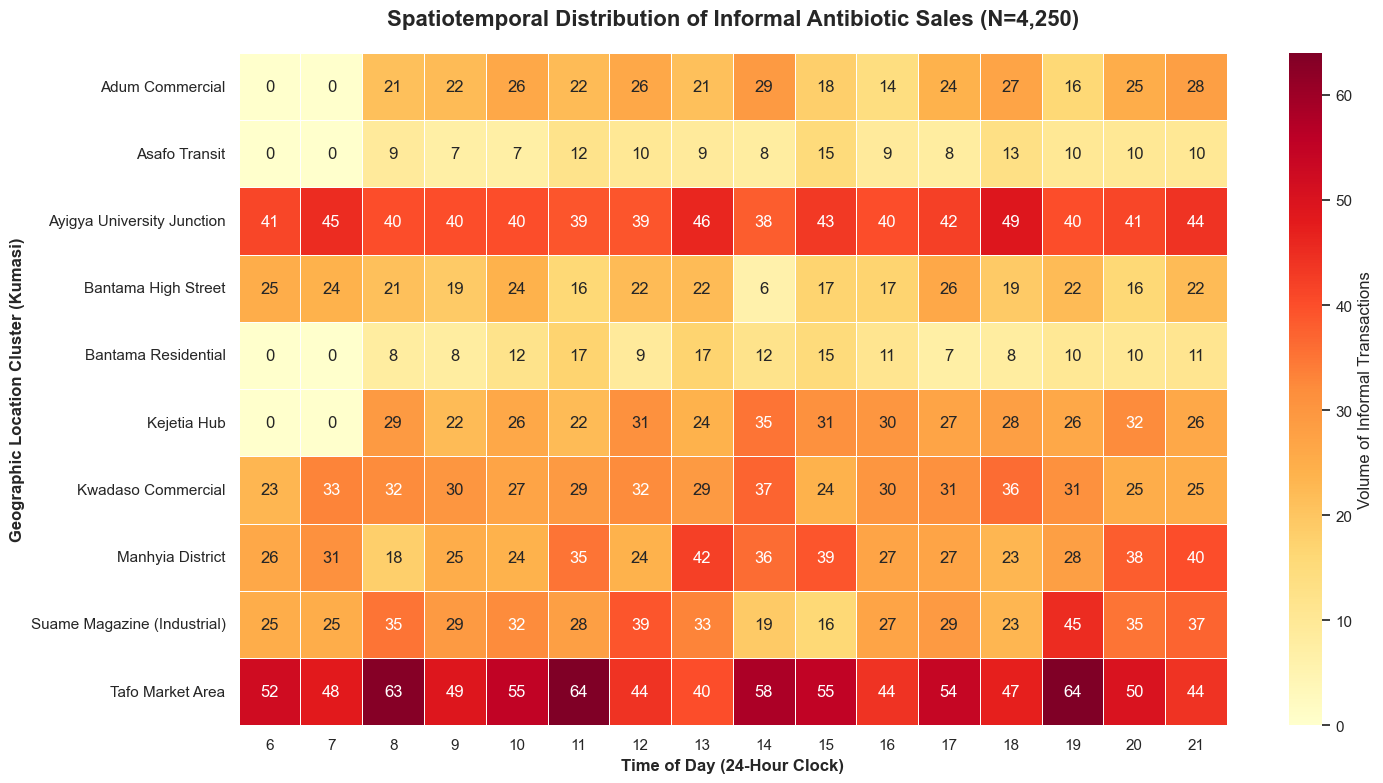

In [504]:
heatmap_data = combined_df.pivot_table(
    index='Location_Cluster', 
    columns='Hour', 
    values='Transaction_ID', 
    aggfunc='count'
).fillna(0).sort_index(axis=1)

# --- VISUALIZATION ---
plt.figure(figsize=(15, 8))

sns.heatmap(
    heatmap_data, 
    cmap='YlOrRd',  
    annot=True,     
    fmt='g',        
    linewidths=.5,  
    cbar_kws={'label': 'Volume of Informal Transactions'}
)

# Titles and Labeling
plt.title('Spatiotemporal Distribution of Informal Antibiotic Sales (N=4,250)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Time of Day (24-Hour Clock)', fontsize=12, fontweight='bold')
plt.ylabel('Geographic Location Cluster (Kumasi)', fontsize=12, fontweight='bold')

# Ensure X-axis labels (hours) are horizontal for easy reading
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### Comprehensive Research Analytics Dashboard

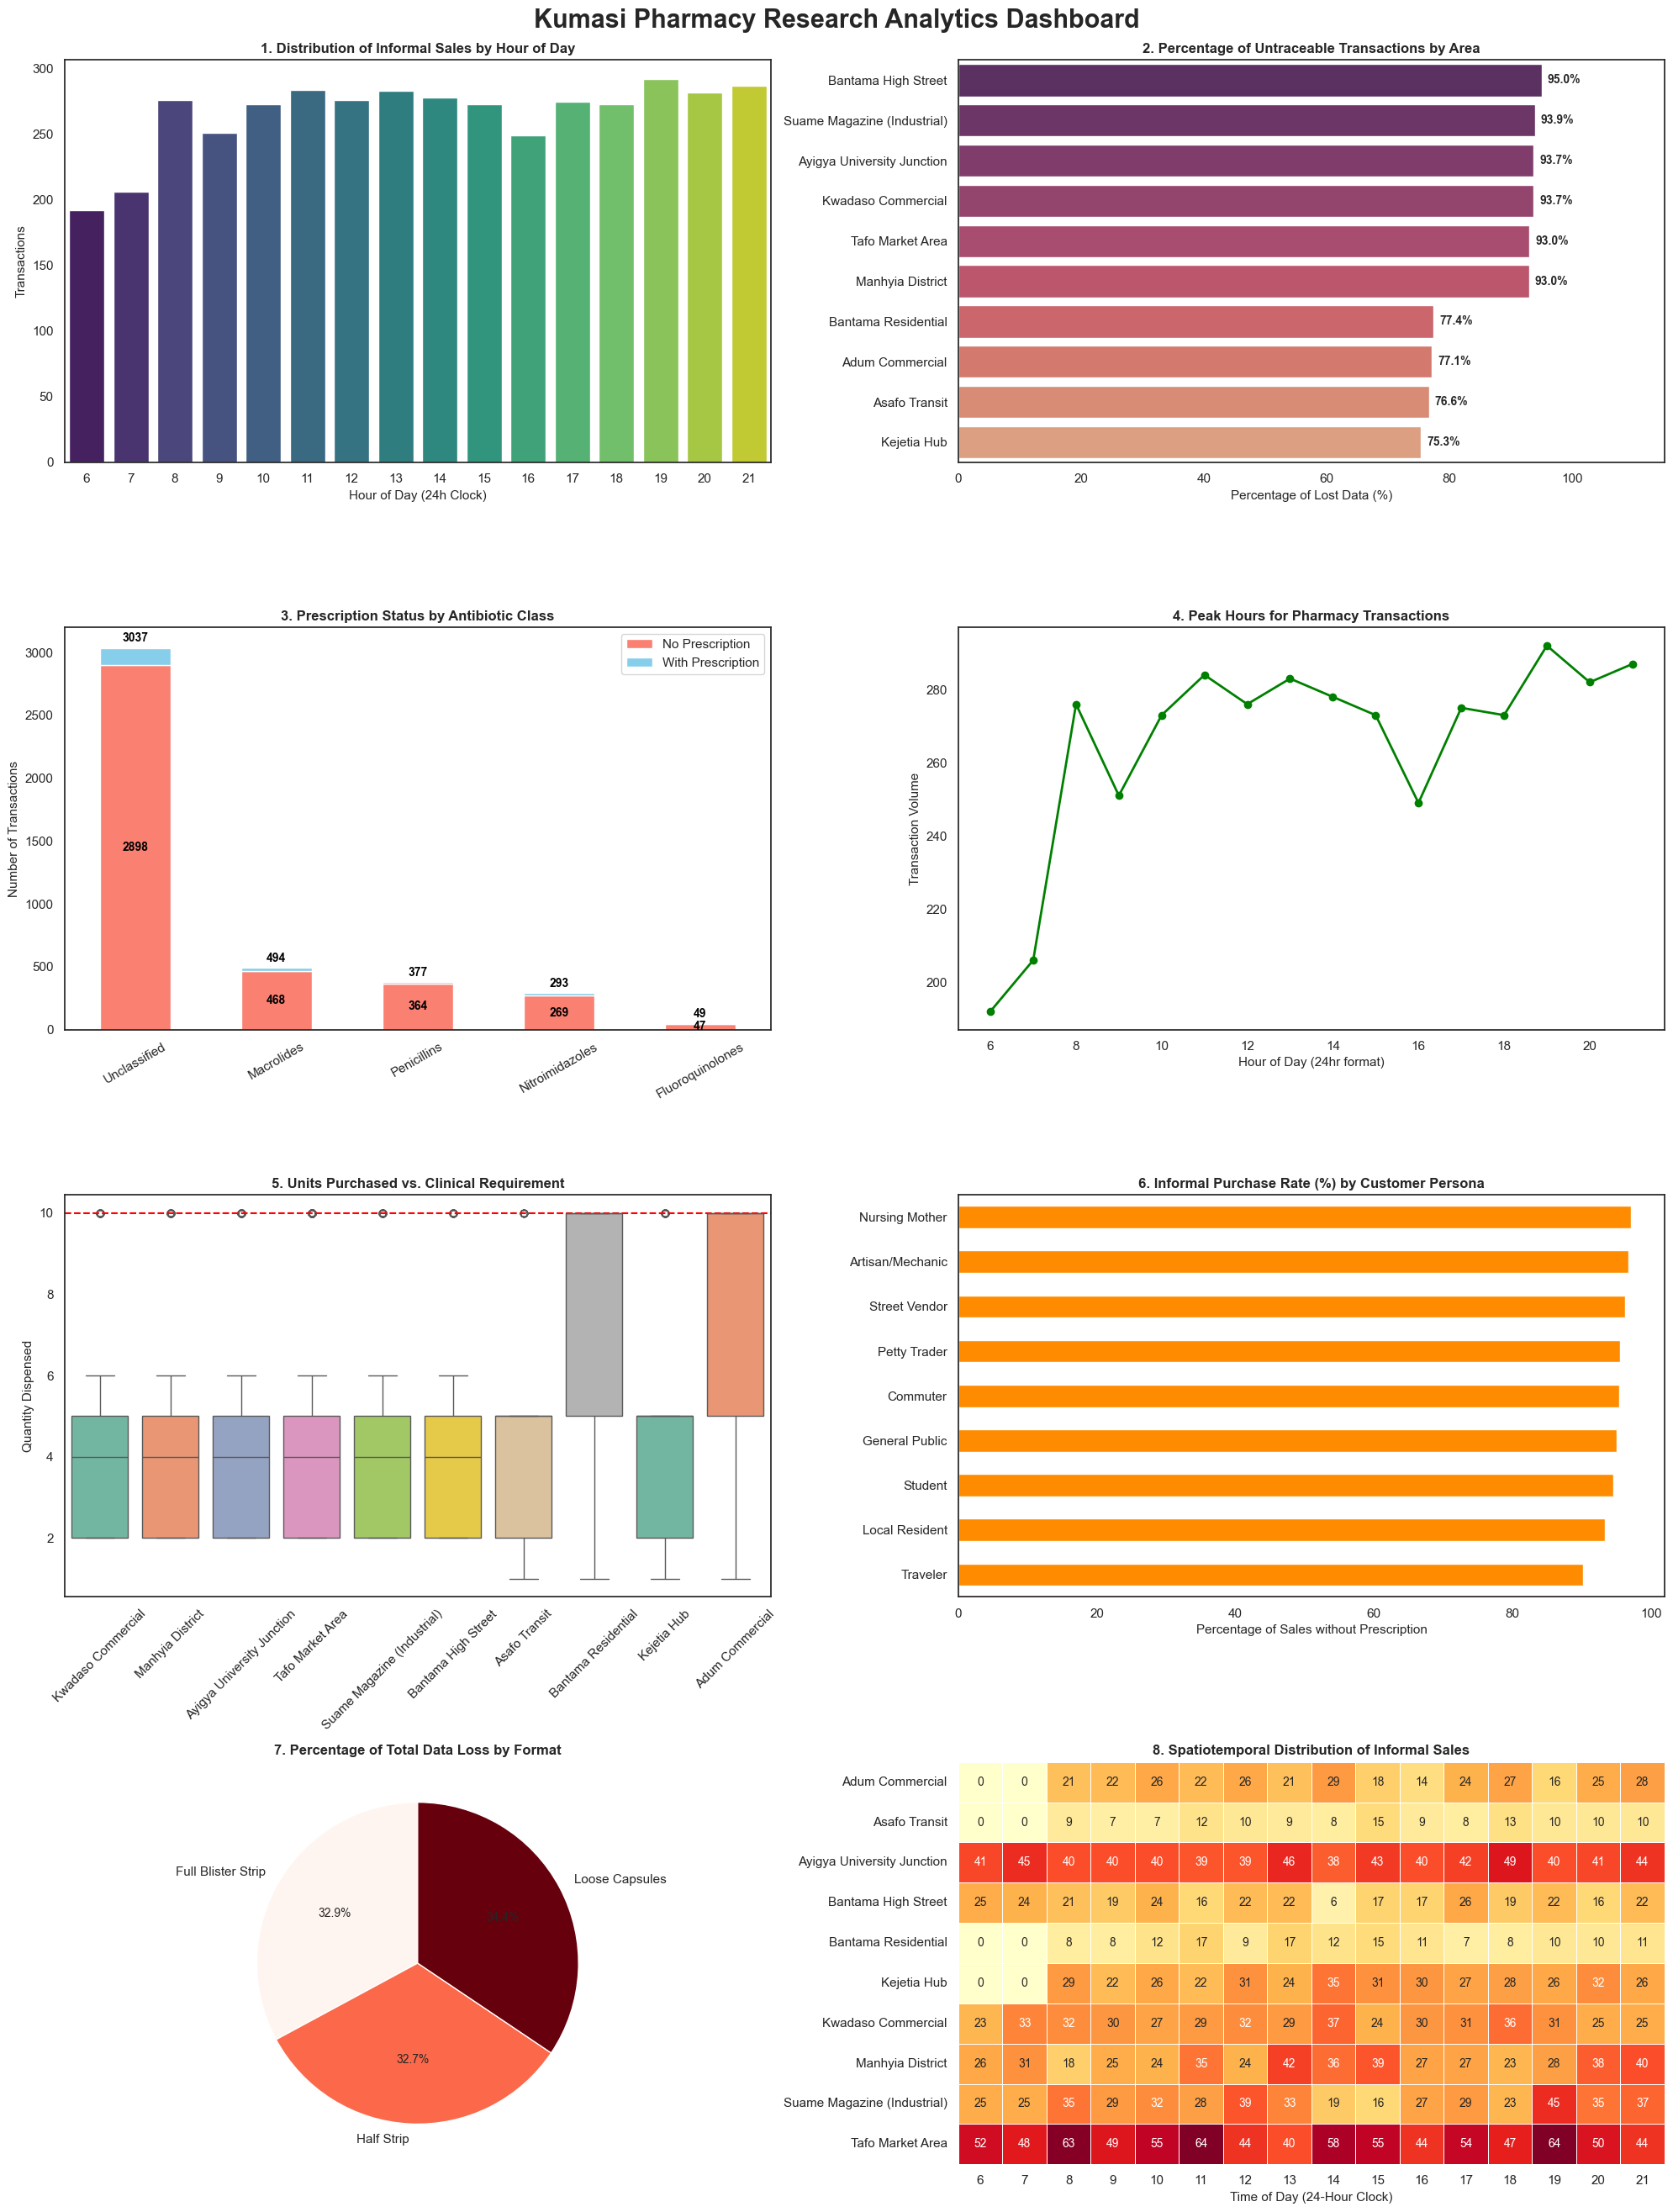

In [505]:
# Set clean, consistent styling for the dashboard
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 12})

# Setting up a 4x2 matrix grid for our 8 primary metrics
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 26))
axes = axes.flatten() # Flatten into a simple list to access axes[0] through axes[7]

# ==========================================
# PLOT 1: Transaction Volume by Hour of Day
# ==========================================
sns.countplot(data=combined_df, x='Hour', hue=combined_df['Hour'].astype(str), 
              palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('1. Distribution of Informal Sales by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour of Day (24h Clock)')
axes[0].set_ylabel('Transactions')
axes[0].grid(False)

# ==========================================
# PLOT 2: Regional Data Traceability Analysis
# ==========================================
# Re-calculate invisible_data on the fly to prevent any missing variable errors
invisible_data = (combined_df.groupby('Location_Cluster')['Data_Loss_Flag'].mean() * 100).reset_index()
invisible_data = invisible_data.sort_values(by='Data_Loss_Flag', ascending=False)

sns.barplot(x='Data_Loss_Flag', y='Location_Cluster', data=invisible_data, 
            hue='Location_Cluster', palette='flare_r', legend=False, ax=axes[1])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold')
axes[1].set_title('2. Percentage of Untraceable Transactions by Area', fontweight='bold')
axes[1].set_xlabel('Percentage of Lost Data (%)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 115)
axes[1].grid(False)

# ==========================================
# PLOT 3: Prescription Status by Antibiotic Class
# ==========================================
risk_analysis = pd.crosstab(combined_df['Antibiotic_Class'], combined_df['Prescription_Status'])
risk_analysis.columns = ['No Prescription', 'With Prescription']
risk_analysis = risk_analysis.loc[risk_analysis.sum(axis=1).sort_values(ascending=False).index]

risk_analysis.plot(kind='bar', stacked=True, color=['salmon', 'skyblue'], ax=axes[2], legend=True)
axes[2].grid(False)
axes[2].bar_label(axes[2].containers[0], label_type='center', color='black', fontweight='bold')
axes[2].bar_label(axes[2].containers[1], label_type='edge', padding=3, color='black', fontweight='bold')
axes[2].set_title('3. Prescription Status by Antibiotic Class', fontweight='bold')
axes[2].set_ylabel('Number of Transactions')
axes[2].set_xlabel('')
axes[2].set_ylim(0, 3200)
axes[2].tick_params(axis='x', rotation=30)

# ==========================================
# PLOT 4: Operational Peak Times Timeline
# ==========================================
hourly_sales = combined_df.groupby('Hour').size()
hourly_sales.plot(kind='line', marker='o', color='green', linewidth=2, ax=axes[3])
axes[3].set_title('4. Peak Hours for Pharmacy Transactions', fontweight='bold')
axes[3].set_xlabel('Hour of Day (24hr format)')
axes[3].set_ylabel('Transaction Volume')
axes[3].grid(False)

# ==========================================
# PLOT 5: Dosage Fragmentation & Compliance Evaluation
# ==========================================
sns.boxplot(x='Location_Cluster', y='Quantity_Dispensed', hue='Location_Cluster', 
            data=combined_df, palette='Set2', legend=False, ax=axes[4])
axes[4].axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='WHO Min. Course')
axes[4].set_title('5. Units Purchased vs. Clinical Requirement', fontweight='bold')
axes[4].set_ylabel('Quantity Dispensed')
axes[4].set_xlabel('')
axes[4].tick_params(axis='x', rotation=45)
axes[4].grid(False)

# ==========================================
# PLOT 6: Customer Risk Profiling
# ==========================================
persona_risk = pd.crosstab(combined_df['Customer_Persona'], combined_df['Prescription_Status'], normalize='index') * 100
persona_risk[0].sort_values().plot(kind='barh', color='darkorange', ax=axes[5])
axes[5].set_title('6. Informal Purchase Rate (%) by Customer Persona', fontweight='bold')
axes[5].set_xlabel('Percentage of Sales without Prescription')
axes[5].set_ylabel('')
axes[5].grid(False)

# ==========================================
# PLOT 7: Data Loss Risk by Packaging
# ==========================================
format_impact = pd.crosstab(combined_df['Dispensing_Format'], combined_df['Data_Loss_Flag'], normalize='index') * 100
format_impact[1].plot(kind='pie', autopct='%1.1f%%', cmap='Reds', ax=axes[6], startangle=90)
axes[6].set_title('7. Percentage of Total Data Loss by Format', fontweight='bold')
axes[6].set_ylabel('')

# ==========================================
# PLOT 8: Spatiotemporal Hotspot Heatmap Matrix
# ==========================================
heatmap_data = combined_df.pivot_table(index='Location_Cluster', columns='Hour', values='Transaction_ID', aggfunc='count').fillna(0)
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='g', linewidths=.5, cbar=False, ax=axes[7])
axes[7].set_title('8. Spatiotemporal Distribution of Informal Sales', fontweight='bold')
axes[7].set_xlabel('Time of Day (24-Hour Clock)')
axes[7].set_ylabel('')

# Final formatting adjustments
plt.tight_layout()
plt.suptitle('Kumasi Pharmacy Research Analytics Dashboard', fontsize=22, fontweight='bold', y=1.01)
plt.show()